# Data Information

This dataset contains medical insurance cost information for 1338 individuals. It includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US. The target variable is charges, which represents the medical insurance cost billed to the individual.

Source: https://doi.org/10.34740/kaggle/dsv/12853160

# Dataset

In [141]:
import pandas as pd

data_df = pd.read_csv("insurance.csv")
data_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


# Problem Definition

## Objective

- use the dataset to estimate insurance bill/cost per person
- identify which variables are most associated with higher or lower insurance bill

## Usecase

Corporate Wellness Program
- Identify high-risk employees based on predicted healthcare costs
- Enable targeted interventions to reduce the company’s overall healthcare expenses

Insurance Company
- Analyze healthcare cost trends across different population segments
- Enable dynamic premium pricing based on individual risk profiles
- Provide personalized insurance plans tailored to each customer

Example Use Case
A person with certain conditions who is predicted to have high healthcare costs can be recommended lifestyle interventions

# Data Preparation

## 1. Data Understanding

In [142]:
print("Shape:", data_df.shape)

Shape: (1338, 7)


In [143]:
print("Columns:", data_df.columns)

Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


In [144]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [145]:
data_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [146]:
data_df.duplicated().sum()

np.int64(1)

In [147]:
data_df = data_df.drop_duplicates()
data_df.duplicated().sum()

np.int64(0)

In [148]:
data_df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [149]:
data_df.describe(include="str")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


# 2. Data Cleaning

## 2.1 Outlier 

In [150]:
num_cols = ['age', 'bmi', 'charges']

for col in num_cols:
    Q1 = data_df[col].quantile(0.25)
    Q3 = data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data_df[(data_df[col] < lower) | (data_df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
charges: 139 outliers


The BMI outlier in this dataset is above ~47.3 (upper bound IQR), with a max of 53.13. This value is included in the Obesity Class III category, which medically actually exists and is documented. This is not a data entry error.

Outlier charges are retained because they are the target variable that the model must predict.

In [151]:
data_df['children'].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [152]:
data_df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [153]:
data_df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [154]:
data_df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

# 3. Data Transformation

## 3.1 Feature Encoding

In [155]:
data_df['gender_encoded'] = data_df['sex'].map({'male': 0, 'female': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [156]:
data_df['smoker_encoded'] = data_df['smoker'].map({'no': 0, 'yes': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded,smoker_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


In [157]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' opsional

region_encoded = encoder.fit_transform(data_df[['region']])

region_columns = encoder.get_feature_names_out(['region'])
region_df = pd.DataFrame(region_encoded, columns=region_columns, index=data_df.index)

data_df = data_df.drop('region', axis=1)
data_df = pd.concat([data_df, region_df], axis=1)

data_df.head(5)

,age,sex,bmi,children,smoker,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,1,1,0.0,0.0,1.0
1,18,male,33.770,1,no,1725.55230,0,0,0.0,1.0,0.0
2,28,male,33.000,3,no,4449.46200,0,0,0.0,1.0,0.0
3,33,male,22.705,0,no,21984.47061,0,0,1.0,0.0,0.0
4,32,male,28.880,0,no,3866.85520,0,0,1.0,0.0,0.0


In [158]:
data_df = data_df.drop(columns=['sex', 'smoker'])
data_df.head(5)

,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


# Data Analysis

## 1. Descriptive Statistics

In [159]:
data_df[['age', 'bmi', 'children', 'charges']].describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


## 2. Inferential Statistics

## 2.1 Normality Test

In [160]:
from scipy import stats

stat, p = stats.shapiro(data_df['charges'])
print(f"Shapiro-Wilk: stat={stat:.4f}, p-value={p:.6f}")
print(f"Skewness: {data_df['charges'].skew():.2f}")

Shapiro-Wilk: stat=0.8148, p-value=0.000000
Skewness: 1.52


Because charges are highly skewed (skewness = 1.52) and the Shapiro-Wilk test rejects normality (p < 0.05), we use non-parametric tests.

## 2.2 Binary Features VS Charges (Mann-Whitney U Test)

In [161]:
from scipy.stats import mannwhitneyu

for col in ['smoker_encoded', 'gender_encoded']:
    group_0 = data_df[data_df[col] == 0]['charges']
    group_1 = data_df[data_df[col] == 1]['charges']
    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')
    print(f"{col}: U={stat:.2f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

smoker_encoded: U=7403.00, p-value=0.000000 --> Significant
gender_encoded: U=226198.00, p-value=0.694479 --> Not Significant


## 2.3 Multi-group Features vs Charges (Kruskal-Wallis Test)

In [162]:
from scipy.stats import kruskal

# Region
data_df['region_label'] = data_df[['region_northwest','region_southeast','region_southwest']].idxmax(axis=1)
data_df.loc[(data_df[['region_northwest','region_southeast','region_southwest']].sum(axis=1) == 0), 'region_label'] = 'region_northeast'

region_groups = [group['charges'].values for name, group in data_df.groupby('region_label')]
stat_r, p_r = kruskal(*region_groups)
print(f"region: H={stat_r:.2f}, p-value={p_r:.6f} --> {'Significant' if p_r < 0.05 else 'Not Significant'}")

# Children
children_groups = [group['charges'].values for name, group in data_df.groupby('children')]
stat_c, p_c = kruskal(*children_groups)
print(f"children: H={stat_c:.2f}, p-value={p_c:.6f} --> {'Significant' if p_c < 0.05 else 'Not Significant'}")

data_df = data_df.drop(columns=['region_label'])

region: H=4.62, p-value=0.201620 --> Not Significant
children: H=29.12, p-value=0.000022 --> Significant


## 2.4 Continuous Features vs Charges (Spearman Correlation)

In [163]:
from scipy.stats import spearmanr

for col in ['age', 'bmi']:
    corr, p = spearmanr(data_df[col], data_df['charges'])
    print(f"{col}: rho={corr:.4f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

age: rho=0.5335, p-value=0.000000 --> Significant
bmi: rho=0.1196, p-value=0.000012 --> Significant


### Inferential Statistics Summary

| Feature | Test | Statistic | p-value | Result |
|---------|------|-----------|---------|--------|
| smoker | Mann-Whitney U | U = 7,403.00 | 0.000000 | **Significant** |
| gender | Mann-Whitney U | U = 226,198.00 | 0.694479 | Not Significant |
| region | Kruskal-Wallis | H = 4.62 | 0.201620 | Not Significant |
| children | Kruskal-Wallis | H = 29.12 | 0.000022 | **Significant** |
| age | Spearman | rho = 0.5335 | 0.000000 | **Significant** (moderate +) |
| bmi | Spearman | rho = 0.1196 | 0.000012 | **Significant** (weak +) |

**Key Findings:**
- **Smoker** is the strongest predictor of charges by far (extremely low p-value)
- **Age** has a moderate positive correlation with charges -- older individuals tend to have higher costs
- **Children** has a significant effect -- the number of dependents influences insurance costs
- **BMI** has a weak but statistically significant positive correlation with charges
- **Gender** and **Region** have no significant effect on charges

## 3. Correlation

                   age   bmi  children  charges  gender_encoded  \
age               1.00  0.11      0.06     0.53            0.02   
bmi               0.11  1.00      0.02     0.12           -0.04   
children          0.06  0.02      1.00     0.13           -0.02   
charges           0.53  0.12      0.13     1.00           -0.01   
gender_encoded    0.02 -0.04     -0.02    -0.01            1.00   
smoker_encoded   -0.03  0.00      0.02     0.66           -0.08   
region_northwest  0.00 -0.13      0.04    -0.02            0.01   
region_southeast -0.02  0.25     -0.02     0.02           -0.02   
region_southwest  0.01  0.00      0.01    -0.04            0.00   

                  smoker_encoded  region_northwest  region_southeast  \
age                        -0.03              0.00             -0.02   
bmi                         0.00             -0.13              0.25   
children                    0.02              0.04             -0.02   
charges                     0.66         

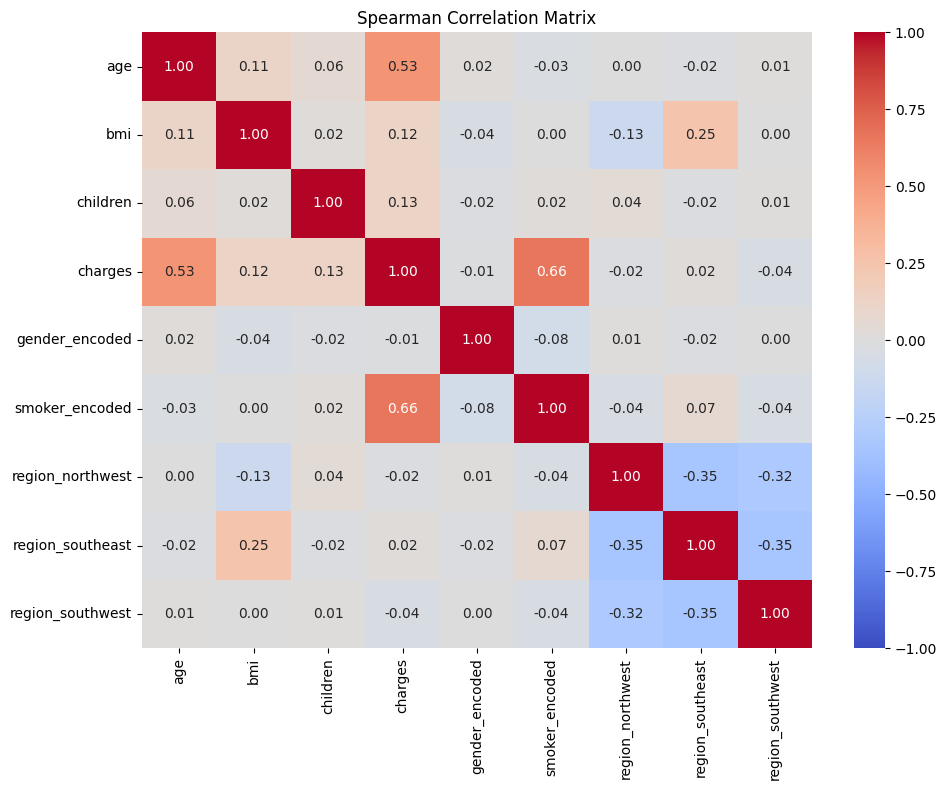

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = data_df.corr(method='spearman').round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

In [166]:
charges_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=False)
print("Correlation with charges (Spearman):\n")
print(charges_corr.to_string())

Correlation with charges (Spearman):

smoker_encoded      0.66
age                 0.53
children            0.13
bmi                 0.12
region_southeast    0.02
gender_encoded     -0.01
region_northwest   -0.02
region_southwest   -0.04


# Development and Data Visualization

In [ ]:
plot_df = pd.read_csv("insurance.csv").drop_duplicates()

## 1. Distribution of Charges

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(plot_df['charges'], bins=40, edgecolor='black', alpha=0.7)
plt.axvline(plot_df['charges'].mean(), color='red', linestyle='--', label=f"Mean: {plot_df['charges'].mean():,.0f}")
plt.axvline(plot_df['charges'].median(), color='orange', linestyle='--', label=f"Median: {plot_df['charges'].median():,.0f}")
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Charges by Smoker

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='smoker', y='charges', order=['no', 'yes'])
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 3. Age vs Charges

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='age', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
plt.title('Age vs Charges (colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 4. BMI vs Charges

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='bmi', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
plt.title('BMI vs Charges (colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 5. Charges by Children

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='children', y='charges', order=sorted(plot_df['children'].unique()))
plt.title('Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 6. Charges by Gender and Region

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='sex', y='charges', order=['male', 'female'], ax=axes[0])
axes[0].set_title('Charges by Gender (Not Significant)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Charges')

sns.boxplot(data=plot_df, x='region', y='charges', order=['northeast', 'northwest', 'southeast', 'southwest'], ax=axes[1])
axes[1].set_title('Charges by Region (Not Significant)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()